<div style="display: flex; align-items: center; justify-content: center; gap: 20px;">
    <img src="https://purepng.com/public/uploads/large/purepng.com-walmart-logologobrand-logoiconslogos-2515199386533ogay.png" alt="Image Gauche" style="width: 400px; height: auto;">
    <div style="font-size: 26px; text-align: center;">
        <h1>
            <span style="font-weight: bold; color:#0071ce; text-decoration: underline;">
                Walmart Project 1
            </span>
        </h1>
    </div>
    <img src="https://purepng.com/public/uploads/large/purepng.com-walmart-logologobrand-logoiconslogos-2515199386533ogay.png" alt="Image Droite" style="width: 400px; height: auto;">
</div>

<h1 style="font-size: 18px; text-align: center; font-style: italic;">
    <span style="font-weight: bold; color:#0071ce">
        Student : Loic VALENTINI
    </span>
</h1>

# **1. Import of libraires and dataset**

In [259]:
# Libraires to import

import pandas as pd
import numpy as np

import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import matplotlib.pyplot as plt

import missingno as msno

import warnings
warnings.filterwarnings("ignore")

In [ ]:
# Dataset import from csv + copy to avoid re-import

dataset_walmart = pd.read_csv("src/Walmart_Store_sales.csv")
dataset = dataset_walmart

# **2. Quick dataset analysis**

In [261]:
# Dataset visualisation

dataset.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,6.0,18-02-2011,1572117.54,NaN,59.61,3.045,214.777523,6.858
1,13.0,25-03-2011,1807545.43,0.0,42.38,3.435,128.616064,7.470
2,17.0,27-07-2012,NaN,0.0,NaN,NaN,130.719581,5.936
3,11.0,NaN,1244390.03,0.0,84.57,NaN,214.556497,7.346
4,6.0,28-05-2010,1644470.66,0.0,78.89,2.759,212.412888,7.092


In [262]:
# Dataset shape

dataset.shape

(150, 8)

<Axes: >

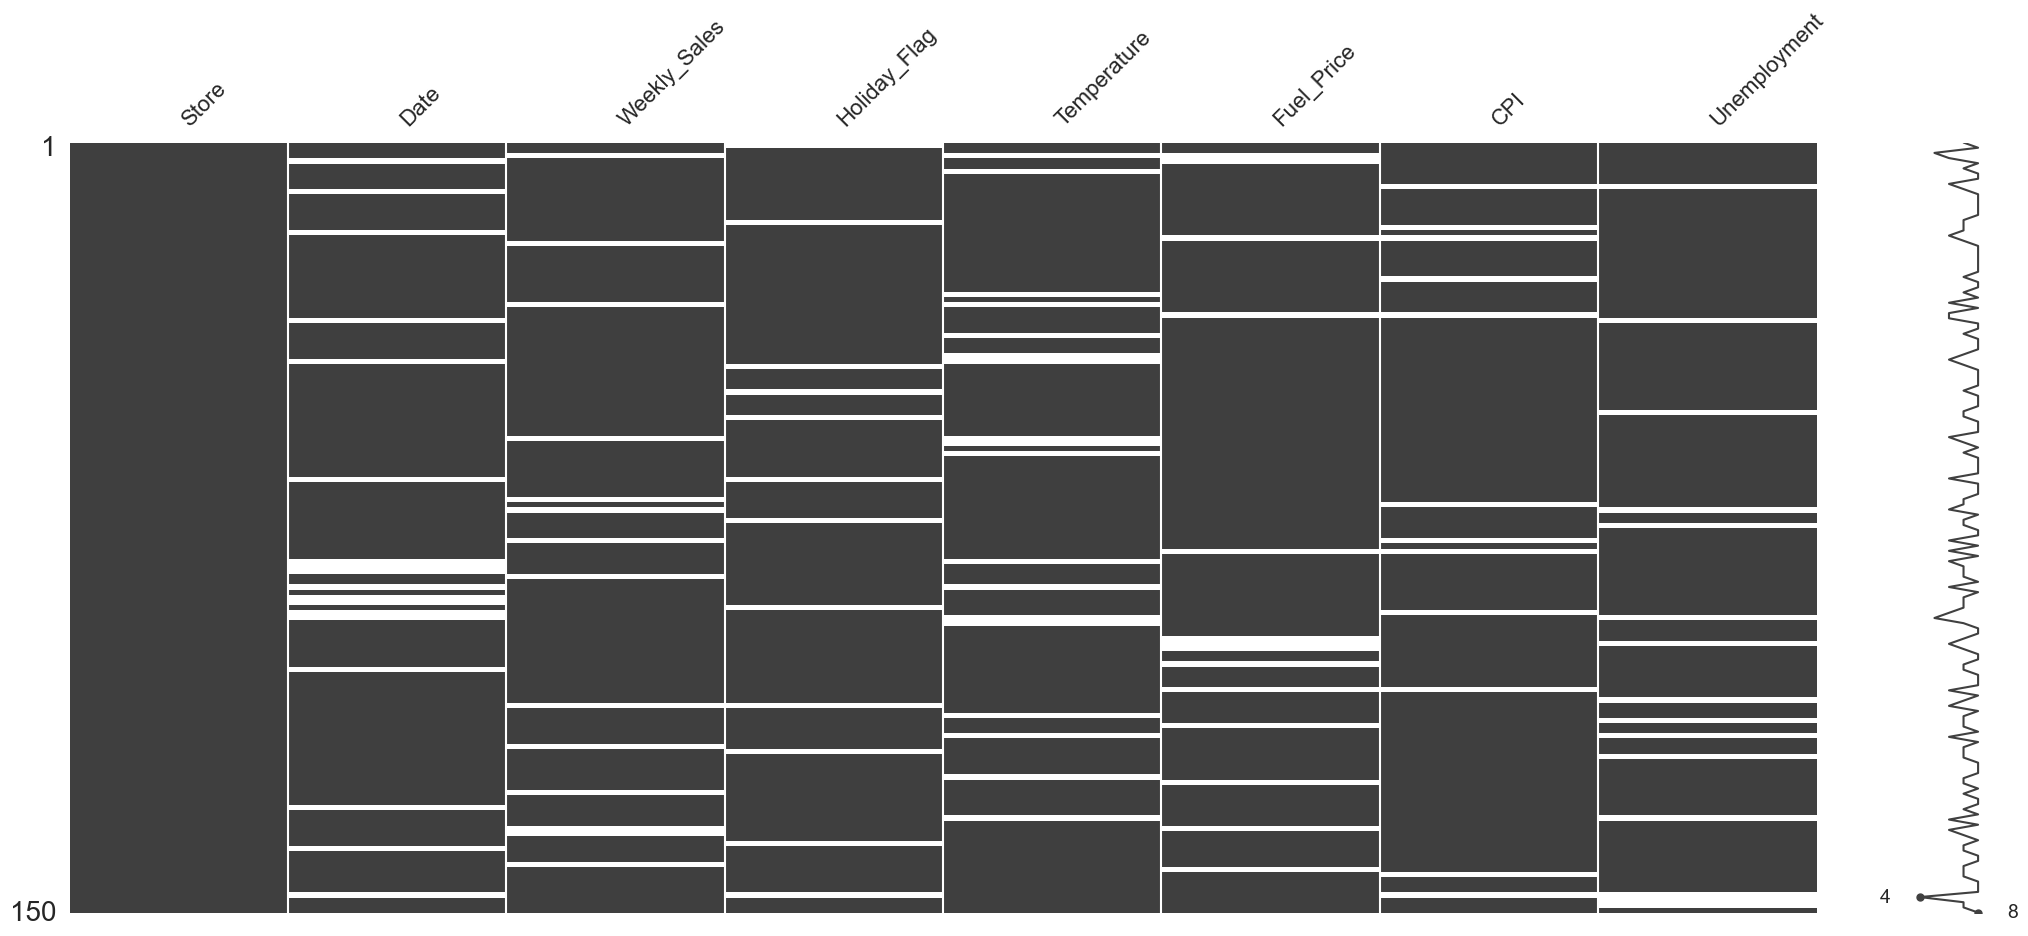

In [263]:
# Are there any missing values ?

msno.matrix(dataset)


<Axes: >

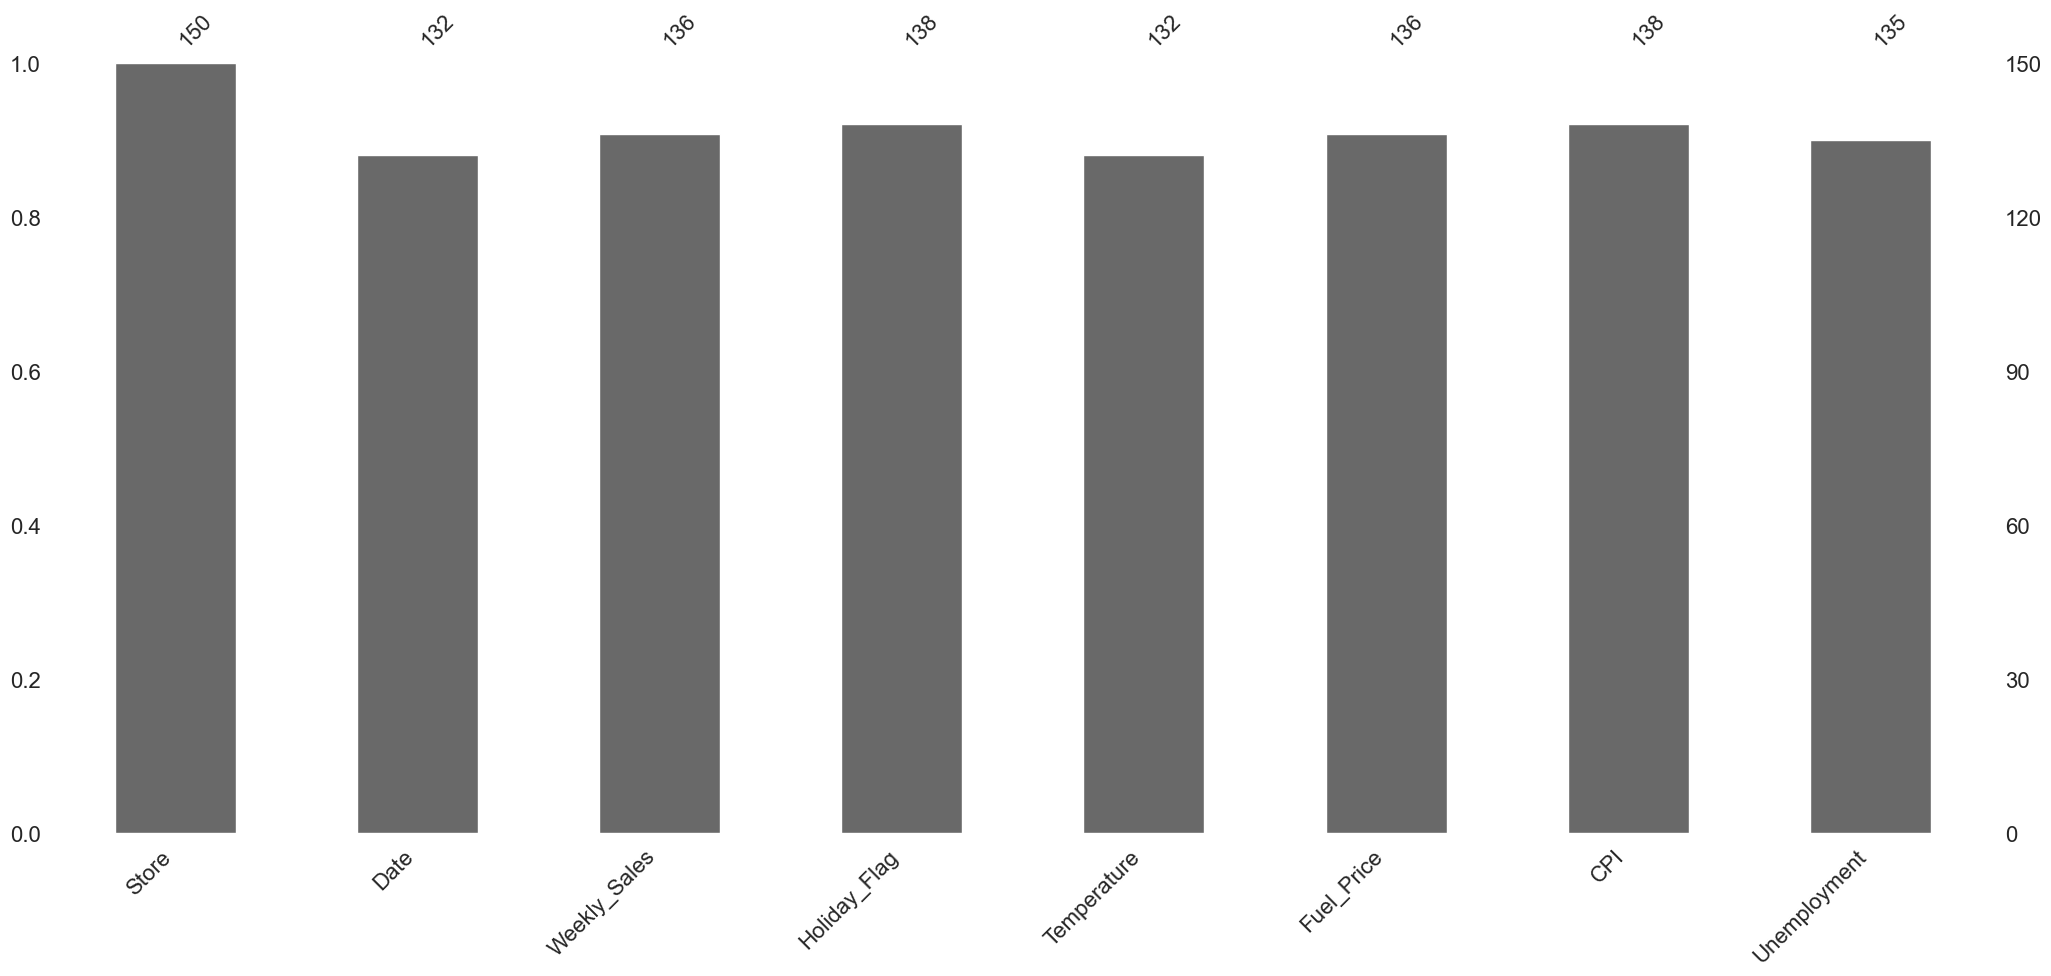

In [264]:
# Number of missing values per column

msno.bar(dataset)

In [265]:
# Quick content check

dataset.describe()

,Store,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
count,150.000000,1.360000e+02,138.000000,132.000000,136.000000,138.000000,135.000000
mean,9.866667,1.249536e+06,0.079710,61.398106,3.320853,179.898509,7.598430
std,6.231191,6.474630e+05,0.271831,18.378901,0.478149,40.274956,1.577173
min,1.000000,2.689290e+05,0.000000,18.790000,2.514000,126.111903,5.143000
25%,4.000000,6.050757e+05,0.000000,45.587500,2.852250,131.970831,6.597500
50%,9.000000,1.261424e+06,0.000000,62.985000,3.451000,197.908893,7.470000
75%,15.750000,1.806386e+06,0.000000,76.345000,3.706250,214.934616,8.150000
max,20.000000,2.771397e+06,1.000000,91.650000,4.193000,226.968844,14.313000


##### There are numeric values only with significant differences between min and max (far more than std). Outlier analysis would be necessary.

# **3. Format check and engineering on date columns**

In [266]:
# Check of columns format

dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         150 non-null    float64
 1   Date          132 non-null    object 
 2   Weekly_Sales  136 non-null    float64
 3   Holiday_Flag  138 non-null    float64
 4   Temperature   132 non-null    float64
 5   Fuel_Price    136 non-null    float64
 6   CPI           138 non-null    float64
 7   Unemployment  135 non-null    float64
dtypes: float64(7), object(1)
memory usage: 9.5+ KB


##### Format of date column must be changed from object to datetime

In [267]:
# Format change

dataset['Date'] = pd.to_datetime(dataset['Date'], dayfirst=True)
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Store         150 non-null    float64       
 1   Date          132 non-null    datetime64[ns]
 2   Weekly_Sales  136 non-null    float64       
 3   Holiday_Flag  138 non-null    float64       
 4   Temperature   132 non-null    float64       
 5   Fuel_Price    136 non-null    float64       
 6   CPI           138 non-null    float64       
 7   Unemployment  135 non-null    float64       
dtypes: datetime64[ns](1), float64(7)
memory usage: 9.5 KB


In [268]:
# Adding of date columns

dataset.loc[:,'Year'] = dataset['Date'].dt.year
dataset.loc[:,'Month'] = dataset['Date'].dt.month
dataset.loc[:,'Day'] = dataset['Date'].dt.day
dataset.loc[:,'DayOfWeek'] = dataset['Date'].dt.dayofweek
dataset.loc[:,'WeekNumber'] = dataset['Date'].dt.isocalendar().week

dataset.head()



,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Year,Month,Day,DayOfWeek,WeekNumber
0,6.0,2011-02-18,1572117.54,NaN,59.61,3.045,214.777523,6.858,2011.0,2.0,18.0,4.0,7
1,13.0,2011-03-25,1807545.43,0.0,42.38,3.435,128.616064,7.470,2011.0,3.0,25.0,4.0,12
2,17.0,2012-07-27,NaN,0.0,NaN,NaN,130.719581,5.936,2012.0,7.0,27.0,4.0,30
3,11.0,NaT,1244390.03,0.0,84.57,NaN,214.556497,7.346,NaN,NaN,NaN,NaN,<NA>
4,6.0,2010-05-28,1644470.66,0.0,78.89,2.759,212.412888,7.092,2010.0,5.0,28.0,4.0,21


In [269]:
# Where are the rows with missing HolidayFlag ?

dataset[dataset['Holiday_Flag'].isna()]

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Year,Month,Day,DayOfWeek,WeekNumber
0,6.0,2011-02-18,1572117.54,NaN,59.61,3.045,214.777523,6.858,2011.0,2.0,18.0,4.0,7
15,6.0,2010-04-30,1498080.16,NaN,68.91,2.780,211.894272,7.092,2010.0,4.0,30.0,4.0,17
43,7.0,2011-08-26,629994.47,NaN,57.60,3.485,194.379637,8.622,2011.0,8.0,26.0,4.0,34
48,1.0,2011-08-05,1624383.75,NaN,91.65,3.684,215.544618,7.962,2011.0,8.0,5.0,4.0,31
53,14.0,2011-03-25,1879451.23,NaN,41.76,3.625,184.994368,8.549,2011.0,3.0,25.0,4.0,12
65,10.0,NaT,1714309.90,NaN,43.43,3.287,127.191774,8.744,NaN,NaN,NaN,NaN,<NA>
73,1.0,2010-08-27,1449142.92,NaN,85.22,2.619,211.567306,7.787,2010.0,8.0,27.0,4.0,34
90,9.0,2010-07-09,485389.15,NaN,78.51,2.642,214.656430,6.442,2010.0,7.0,9.0,4.0,27
109,1.0,2011-12-09,NaN,NaN,43.93,3.158,218.961846,7.866,2011.0,12.0,9.0,4.0,49
118,9.0,2010-06-18,513073.87,NaN,82.99,2.637,215.016648,6.384,2010.0,6.0,18.0,4.0,24


##### If dates are available, we can intelligently impute the Holiday_Flag using external data (U.S. holidays).

In [270]:
# Creation of a holiday_flag dataframe on the 2010-2012 period

holiday_events = {
    'Super Bowl': ['12-Feb-10', '11-Feb-11', '10-Feb-12'],
    'Labour Day': ['10-Sep-10', '9-Sep-11', '7-Sep-12'],
    'Thanksgiving': ['26-Nov-10', '25-Nov-11', '23-Nov-12'],
    'Christmas': ['31-Dec-10', '30-Dec-11', '28-Dec-12']
}

# Dataframe creation from the dictionary

holiday_data = []
for event, dates in holiday_events.items():
    for date in dates:
        holiday_data.append([event, date])

holiday_df = pd.DataFrame(holiday_data, columns=['Event', 'Date'])

# Format coherence and date column creation

holiday_df['Date'] = pd.to_datetime(holiday_df['Date'], format='%d-%b-%y')
holiday_df['WeekNumber'] = holiday_df['Date'].dt.isocalendar().week
holiday_df['Year'] = holiday_df['Date'].dt.isocalendar().year


holiday_df

,Event,Date,WeekNumber,Year
0,Super Bowl,2010-02-12,6,2010
1,Super Bowl,2011-02-11,6,2011
2,Super Bowl,2012-02-10,6,2012
3,Labour Day,2010-09-10,36,2010
4,Labour Day,2011-09-09,36,2011
5,Labour Day,2012-09-07,36,2012
6,Thanksgiving,2010-11-26,47,2010
7,Thanksgiving,2011-11-25,47,2011
8,Thanksgiving,2012-11-23,47,2012
9,Christmas,2010-12-31,52,2010


In [271]:
# Merge of dataset with holiday_df

dataset = dataset.merge(holiday_df[['WeekNumber','Year', 'Event']], on=['WeekNumber','Year'], how='left')
dataset.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Year,Month,Day,DayOfWeek,WeekNumber,Event
0,6.0,2011-02-18,1572117.54,NaN,59.61,3.045,214.777523,6.858,2011.0,2.0,18.0,4.0,7,NaN
1,13.0,2011-03-25,1807545.43,0.0,42.38,3.435,128.616064,7.470,2011.0,3.0,25.0,4.0,12,NaN
2,17.0,2012-07-27,NaN,0.0,NaN,NaN,130.719581,5.936,2012.0,7.0,27.0,4.0,30,NaN
3,11.0,NaT,1244390.03,0.0,84.57,NaN,214.556497,7.346,NaN,NaN,NaN,NaN,<NA>,NaN
4,6.0,2010-05-28,1644470.66,0.0,78.89,2.759,212.412888,7.092,2010.0,5.0,28.0,4.0,21,NaN


In [272]:
# Imputation of Holiday_Flag values using masks

# Values 1
mask_holiday_1 = (dataset['Holiday_Flag'].isna() & dataset['Date'].notna() & dataset['Event'].notna())
dataset.loc[mask_holiday_1, 'Holiday_Flag'] = 1

# Values 0
mask_holiday_0 = (dataset['Holiday_Flag'].isna() & dataset['Date'].notna())
dataset.loc[mask_holiday_0, 'Holiday_Flag'] = 0

dataset.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Store         150 non-null    float64       
 1   Date          132 non-null    datetime64[ns]
 2   Weekly_Sales  136 non-null    float64       
 3   Holiday_Flag  148 non-null    float64       
 4   Temperature   132 non-null    float64       
 5   Fuel_Price    136 non-null    float64       
 6   CPI           138 non-null    float64       
 7   Unemployment  135 non-null    float64       
 8   Year          132 non-null    float64       
 9   Month         132 non-null    float64       
 10  Day           132 non-null    float64       
 11  DayOfWeek     132 non-null    float64       
 12  WeekNumber    132 non-null    UInt32        
 13  Event         10 non-null     object        
dtypes: UInt32(1), datetime64[ns](1), float64(11), object(1)
memory usage: 16.1+ KB


##### All missing Holiday_Flag values, where dates were available, have been imputed.

# **4. Exploratory Data Analysis**

### **4a. Weekly Sales per date**

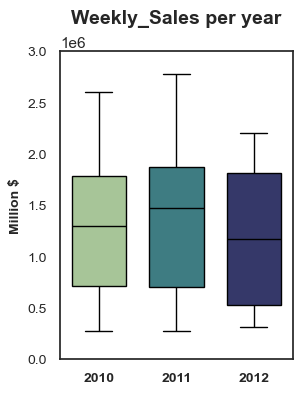

In [273]:
# Weekly_Sales per year

sns.set(rc={'figure.figsize':(3, 4)}, style='white')
colors = sns.color_palette("crest", as_cmap=True)
sns.boxplot(x="Year", y="Weekly_Sales", hue="Year", data=dataset, palette=colors, linecolor='black', width=.7)
plt.title('Weekly_Sales per year', fontsize=14, pad=20, fontweight = 'bold')
plt.ylabel('Million $', fontsize=10, fontweight='bold')
plt.xlabel('')
plt.yticks([i for i in range(0,3500000, 500000)], fontsize=10)
plt.xticks([i for i in range(0,3)], ['2010', '2011', '2012'], fontsize=10, fontweight='bold')
plt.legend('', frameon=False)
plt.show()


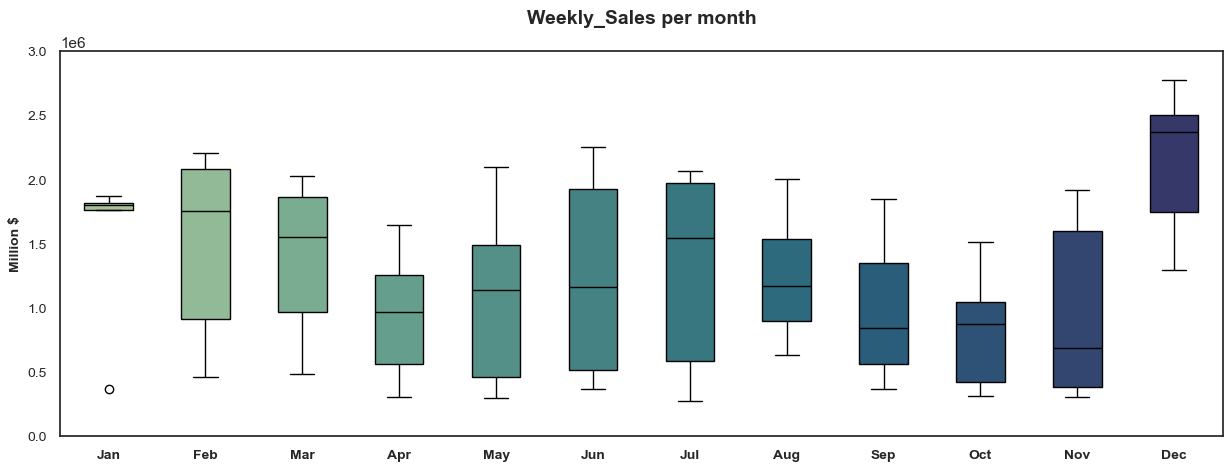

In [274]:
# Weekly_Sales per month

sns.set(rc={'figure.figsize':(15, 5)}, style='white')
colors = sns.color_palette("crest", as_cmap=True)
sns.boxplot(x="Month", y="Weekly_Sales", hue="Month", data=dataset,  palette=colors, linecolor='black', width=.5)
plt.title('Weekly_Sales per month', fontsize=14, pad=20, fontweight = 'bold')
plt.ylabel('Million $', fontsize=10, fontweight='bold')
plt.xlabel('')
plt.yticks([i for i in range(0,3500000, 500000)], fontsize=10)
plt.xticks([i for i in range(0,12)], ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'], fontsize=10, fontweight='bold')
plt.legend('', frameon=False)
plt.show()

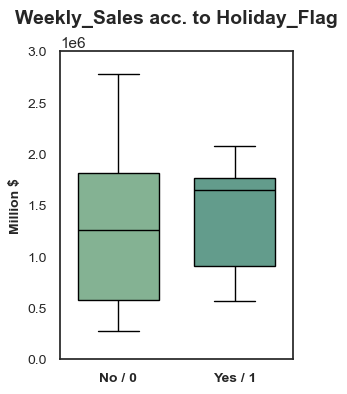

In [275]:
# Weekly_Sales per Holiday_Flag

sns.set(rc={'figure.figsize':(3, 4)}, style='white')
colors = sns.color_palette("crest")
sns.boxplot(x="Holiday_Flag", y="Weekly_Sales", data=dataset, palette=colors, linecolor='black', width=.7)
plt.title('Weekly_Sales acc. to Holiday_Flag', fontsize=14, pad=20, fontweight = 'bold')
plt.ylabel('Million $', fontsize=10, fontweight='bold')
plt.xlabel('')
plt.yticks([i for i in range(0,3500000, 500000)], fontsize=10)
plt.xticks([i for i in range(0,2)], ['No / 0', 'Yes / 1'], fontsize=10, fontweight='bold')
plt.legend('', frameon=False)
plt.show()

##### Based on these graphs, the most significant conclusions that can be detected are:

##### **1️⃣ No clear variation over the years** 
- Average values change little between 2010 and 2012.  
- Compared to the standard deviation, we are within the uncertainty range.  

##### **2️⃣ A noticeable seasonality**  
- Significant variations can be detected depending on the months of the year.  
- Peaks are notably observed during the winter (Dec-Mar) and summer (Jun-Jul) periods.  
- However, the dataset remains limited in quantity, with high standard deviations that do not allow for definitive conclusions.  

##### **3️⃣ An impact from public holidays?**  
- Given the uncertainty and the low number of data points related to public holidays (only 11 rows, less than 10% of the dataset), it is impossible to conclude formally.  
- The much higher median suggests an increase in sales during this period, which seems to confirm something one might expect.


### **4b. Weekly Sales vs other features**

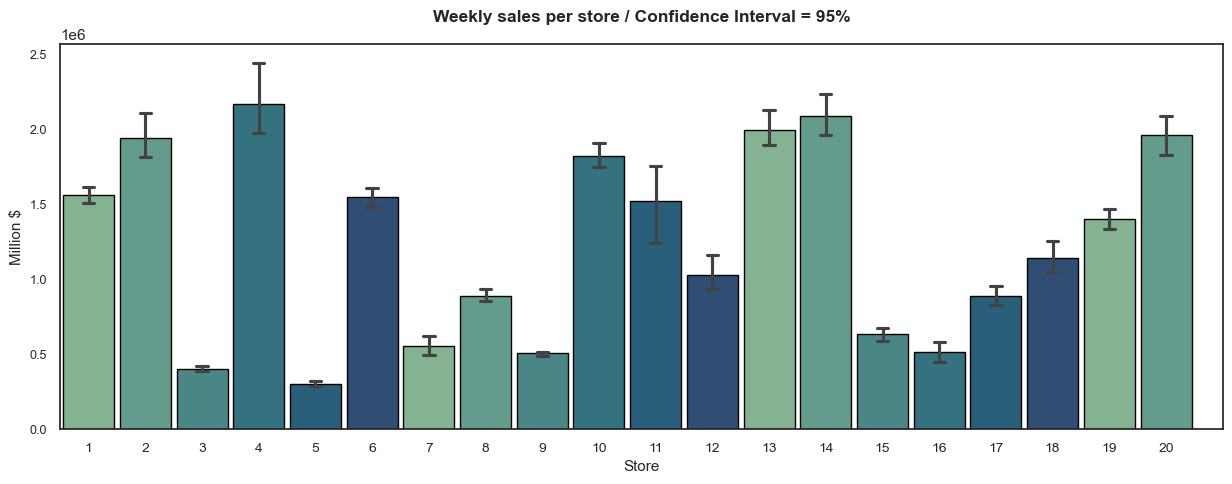

In [276]:
# Weekly_Sales per store

sns.set(rc={'figure.figsize':(15, 5)}, style='white')
colors = sns.color_palette("crest")
sns.barplot(x="Store", y="Weekly_Sales", data=dataset, palette=colors, edgecolor='black', width=0.9, hue="Store", legend=False,  ci=95, capsize=0.2)           
plt.title('Weekly sales per store / Confidence Interval = 95%', fontsize=12.5, pad=16 , fontweight='bold')
plt.ylabel('Million $', fontsize=11)
plt.xlabel('Store', fontsize=11)
plt.yticks([i for i in range(0,3000000, 500000)], fontsize=9)
plt.xticks([i for i in range(0,21)],[1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,''], fontsize=10)
plt.show()

##### Given the lack of connection between stores (geographical? city size?), no trend conclusions can be drawn. However, it should be noted that the impact of each store is highly significant in sales evaluation.

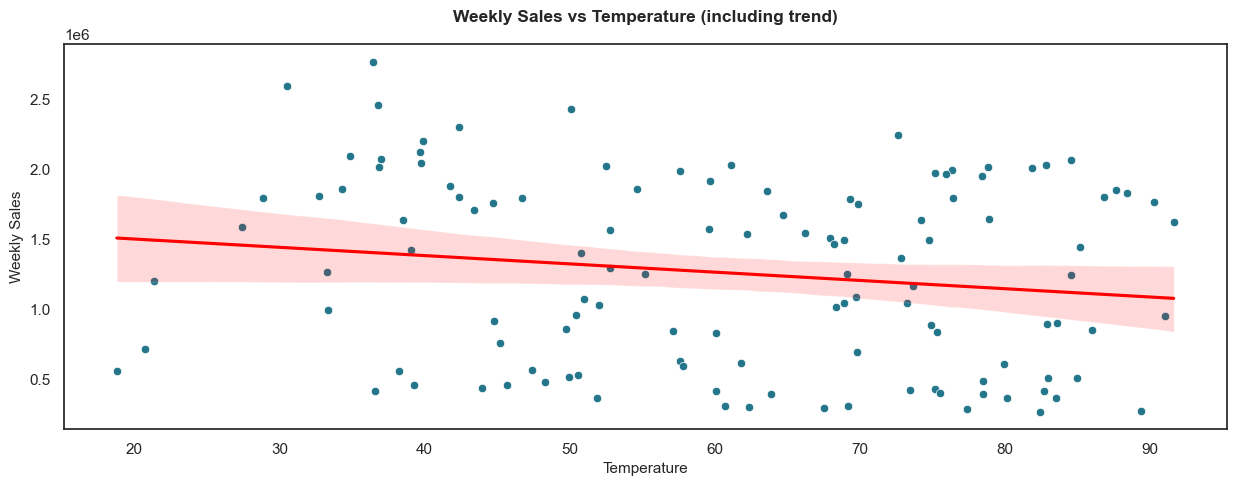

In [277]:
# Weekly_Sales per temperature (including trend)

sns.set(rc={'figure.figsize': (15, 5)}, style='white')
colors = sns.color_palette("crest", as_cmap=True)
sns.scatterplot(x='Temperature', y='Weekly_Sales', data=dataset, color=colors(0.6))

# Trend line
sns.regplot(x='Temperature', y='Weekly_Sales', data=dataset, scatter=False, line_kws={'color': 'red'})

plt.title('Weekly Sales vs Temperature (including trend)', fontsize=12.5, pad=16, fontweight='bold')
plt.xlabel('Temperature', fontsize=11)
plt.ylabel('Weekly Sales', fontsize=11)

plt.show()

##### Temperature does not appear to be a major factor directly influencing weekly sales. Here are some specific analysis

##### **1️⃣ No Clear Correlation** 
- The points appear scattered without following a clear trend (slight minor decrease). 
- This suggests that there is no strong relationship between temperature and weekly sales. 

##### **2️⃣ Wide Dispersion**  
- Sales vary significantly for the same temperature. 
- Even at similar temperatures, sales can be either high or low.

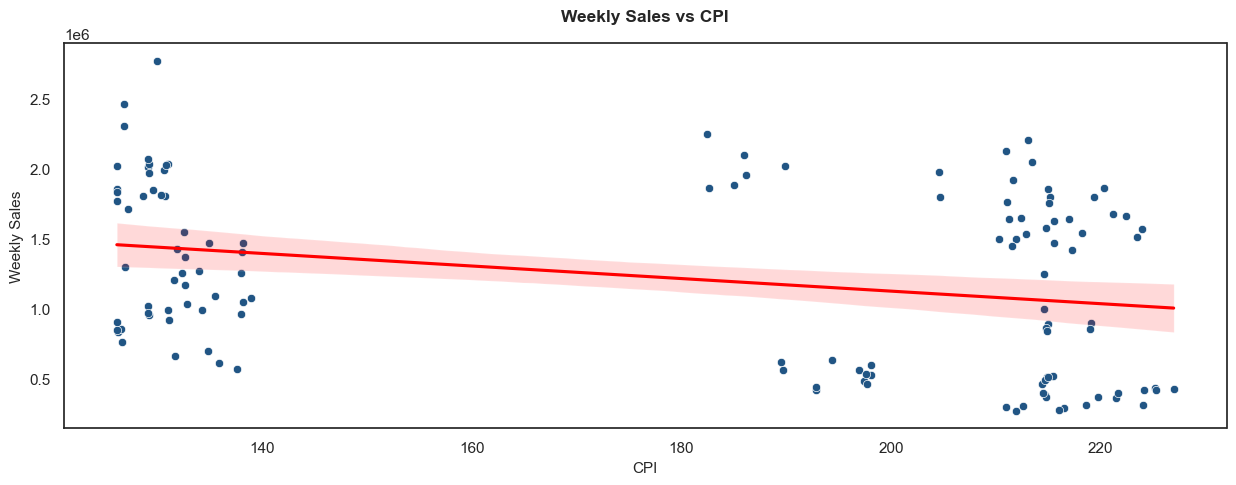

In [278]:
# Weekly_Sales per CPI

plt.figure(figsize=(15, 5))
colors = sns.color_palette("crest", as_cmap=True)
sns.scatterplot(x='CPI', y='Weekly_Sales', data=dataset, color=colors(0.8))

# Trend line
sns.regplot(x='CPI', y='Weekly_Sales', data=dataset, scatter=False, line_kws={'color': 'red'})

plt.title('Weekly Sales vs CPI', fontsize=12.5, pad=16, fontweight='bold')
plt.xlabel('CPI', fontsize=11)
plt.ylabel('Weekly Sales', fontsize=11)
plt.show()


##### CPI alone does not seem to be a key indicator of sales. Here are some further elements.

##### **1️⃣ Grouped Distribution** 
- Instead of a homogeneous cloud of points, we observe several distinct groups.
- This suggests that the data might be segmented might be based on another factor ? (according to previous graph, probably the store?)

##### **2️⃣ A Moderate Linear Relationship**  
- Sales appear highly variable for similar CPI levels.
- There seems to be a moderate decreasing trend showing that an increase in CPI leads to lower sales.

##### **3️⃣ Concentration Zones**  
- There are two strong clusters: around CPI ≈ 130-140, with high and widely dispersed sales & around CPI ≈ 210-230, with lower sales and tighter dispersion.


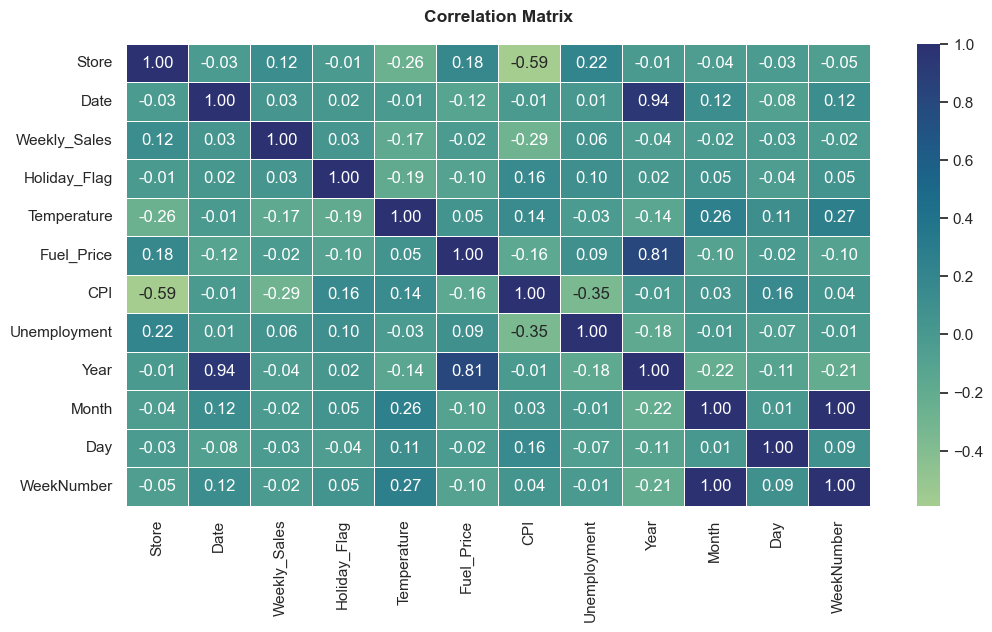

In [279]:
# Correlation matrix 

corr_matrix = (dataset.drop(columns=['Event','DayOfWeek'])).corr().round(2)
sns.set(rc={'figure.figsize': (12, 6)}, style='white')
plt.figure()
sns.heatmap(corr_matrix, annot=True, cmap="crest", fmt=".2f", linewidths=0.5, cbar=True)
plt.title('Correlation Matrix', fontsize=12.5, pad=16, fontweight='bold')
plt.show()


##### Matrix correlation analysis:


##### **1️⃣ Relation with Weekly_Sales**  
- **`Store` (0.13)** : Low positive correlation.
- **`Holiday_Flag` (0.03)** : Very low impact / No impact.
- **`Temperature` (-0.19)** : Low negative correlation.
- **`Fuel_Price` (-0.02)** : Very low impact / No impact.
- **`CPI` (-0.36)** : Moderate negative impact.
- **`Unemployment` (0.18)** : Light positive correlation. (Could be normal for low-cost stores ?)

##### **2️⃣ Other interesting relationships**  
- **`Fuel_Price` & `Date` (0.81)** : Strong correlation, likely driven by oil prices.  
- **`Year` & `Fuel_Price` (0.83)** : Similar trend as above. 
- **`CPI` & `Store` (-0.61)** : Potentially linked to geographical factors.



# **5. Dataset simplification for future Machine Learning**

In [280]:
# Column Event and Day of Week are not necessary anymore

dataset = dataset.drop(columns=["Event","DayOfWeek"])
dataset.columns

Index(['Store', 'Date', 'Weekly_Sales', 'Holiday_Flag', 'Temperature',
       'Fuel_Price', 'CPI', 'Unemployment', 'Year', 'Month', 'Day',
       'WeekNumber'],
      dtype='object')

In [281]:
# Removing rows where the date is missing (not usable) or sales are missing (useless as it's the future target)

dataset = dataset[dataset['Date'].notna() & dataset['Weekly_Sales'].notna()]
dataset.info()

<class 'pandas.core.frame.DataFrame'>
Index: 118 entries, 0 to 149
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Store         118 non-null    float64       
 1   Date          118 non-null    datetime64[ns]
 2   Weekly_Sales  118 non-null    float64       
 3   Holiday_Flag  118 non-null    float64       
 4   Temperature   107 non-null    float64       
 5   Fuel_Price    107 non-null    float64       
 6   CPI           109 non-null    float64       
 7   Unemployment  107 non-null    float64       
 8   Year          118 non-null    float64       
 9   Month         118 non-null    float64       
 10  Day           118 non-null    float64       
 11  WeekNumber    118 non-null    UInt32        
dtypes: UInt32(1), datetime64[ns](1), float64(10)
memory usage: 11.6 KB


##### From 150 to 118 rows. Let's have a look on outliers.

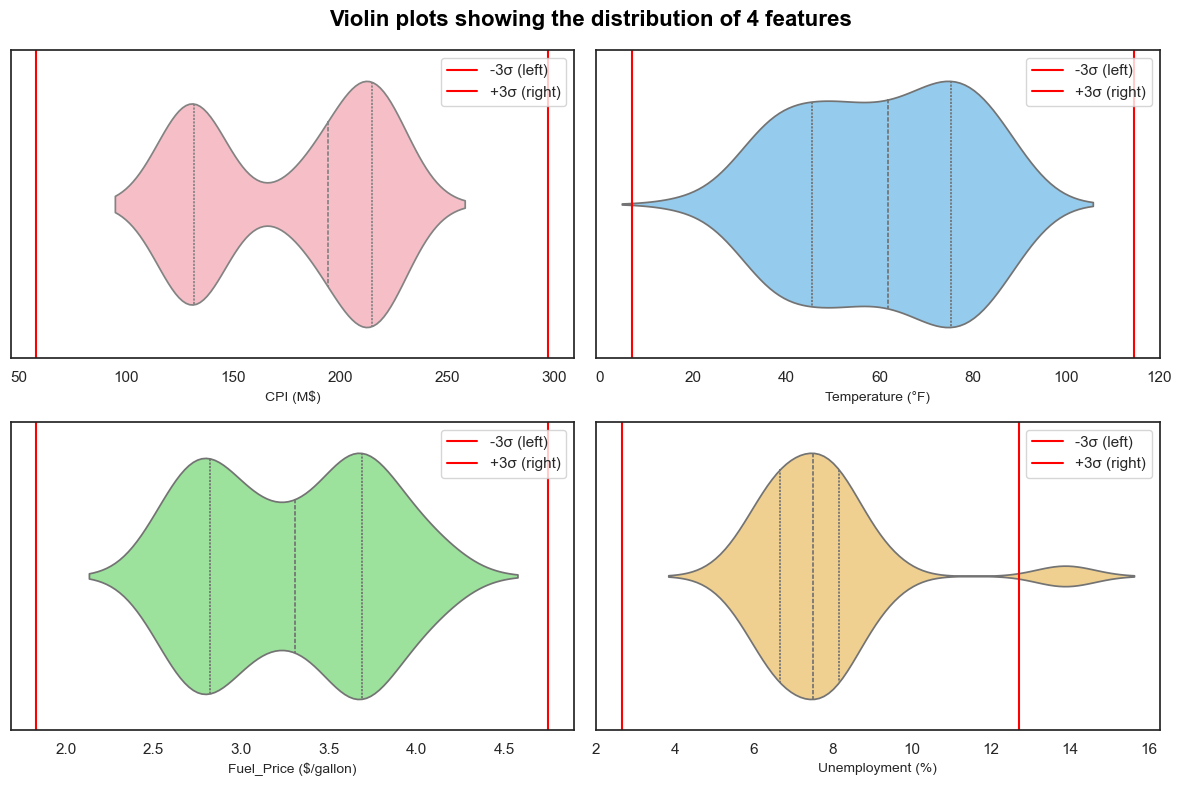

In [ ]:
# Violin plot of 4 features : CPI/Temperature/Fuel_Price/Unemployment

columns = ['CPI', 'Temperature', 'Fuel_Price', 'Unemployment']
colors = ['#FFB6C1', '#87CEFA', '#90EE90', '#FFD580']
units = ['M$', '°F', '$/gallon', '%']

# 2x2 figure

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Loop to create each violin plot

for i, col in enumerate(columns):
    row, col_idx = divmod(i, 2)  # generation of pos 1,1/2,2/1,2/2

    mean_val = dataset[col].mean()
    std_val = dataset[col].std()
    upper_threshold = mean_val + 3 * std_val
    lower_threshold = mean_val - 3 * std_val

    # Violin plot creation
    sns.violinplot(x=dataset[col], ax=axes[row, col_idx], color=colors[i], inner="quart")

    # 2 vertical lines at --3std/+3std
    axes[row, col_idx].axvline(lower_threshold, color='red', linestyle='solid', label="-3σ (left)")
    axes[row, col_idx].axvline(upper_threshold, color='red', linestyle='solid', label="+3σ (right)")

    # title and labels
    axes[row, col_idx].set_xlabel(col + " "+ f"({units[i]})", fontsize=10)
    axes[row, col_idx].legend(loc="upper right")
    plt.suptitle("Violin plots showing the distribution of 4 features", fontsize=16, fontweight='bold', color='black')

plt.tight_layout()
plt.show()


##### Based on the distribution plot, it appears that some values may be considered outliers, and we will remove them.

In [283]:
# Delete outliers

for column in ['Temperature', 'Fuel_Price', 'CPI', 'Unemployment']:
    dataset = dataset[(dataset[column] > dataset[column].mean() - 3 * dataset[column].std() ) &
                      (dataset[column] < dataset[column].mean() + 3 * dataset[column].std() ) |
                       dataset[column].isna()]
    
dataset.info()

<class 'pandas.core.frame.DataFrame'>
Index: 113 entries, 0 to 149
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Store         113 non-null    float64       
 1   Date          113 non-null    datetime64[ns]
 2   Weekly_Sales  113 non-null    float64       
 3   Holiday_Flag  113 non-null    float64       
 4   Temperature   103 non-null    float64       
 5   Fuel_Price    102 non-null    float64       
 6   CPI           104 non-null    float64       
 7   Unemployment  102 non-null    float64       
 8   Year          113 non-null    float64       
 9   Month         113 non-null    float64       
 10  Day           113 non-null    float64       
 11  WeekNumber    113 non-null    UInt32        
dtypes: UInt32(1), datetime64[ns](1), float64(10)
memory usage: 11.1 KB


In [284]:
# Column Date is not necessary anymore

dataset = dataset.drop(columns=["Date"])
dataset.columns

Index(['Store', 'Weekly_Sales', 'Holiday_Flag', 'Temperature', 'Fuel_Price',
       'CPI', 'Unemployment', 'Year', 'Month', 'Day', 'WeekNumber'],
      dtype='object')

##### We will work on a 113-row dataset on the Machine Learning part.

# **6. Dataset saving for future Machine Learning training**

In [285]:
# CSV Saving

dataset.to_csv("Walmart_simplified_dataset.csv", index=False)